### Imports and Constants

In [ ]:
import sys
sys.path.append('../')

from gam_rs_utils.utils import *
from method_scripts.results import *
from method_scripts.base_method import *

In [ ]:
def collate_datasets_results():
    all_datasets_results = {}
    for dn in DATASET_NAMES:
        runs = list()
        for fn in os.listdir(f"../results/{dn}/method_results"):
            result = Results.load_result(f"../results/{dn}/method_results/{fn}")
            runs.append(result.to_dataframe_row())
        all_datasets_results[dn] = pd.concat(runs, axis=0, ignore_index=True)
    return all_datasets_results

def populate_datasets_results(all_datasets_results, n_samples):
    support_set_metrics = [Metrics.inverse_IoU, Metrics.euclidean_distance, Metrics.inverse_cosine_similarity]
    prediction_metrics = ['accuracy', 'logistic']
    logit_metrics = [Metrics.compute_logit_variance, Metrics.compute_logit_pairwise_distance]
    feature_metrics = []
    # do hamming, model count, 

    for dn, df in all_datasets_results.items():
        new_cols = defaultdict(list)
        for i, row in df.iterrows():
            # load rashomon set for this run
            w_rset = row['w_rset']
            w_opt = row['w_opt']
            ne = row['n_estimators']

            # load dataset used for this run
            dataset = Results.load_binarized_dataset(dn, ne)
            X = dataset['X']
            y = dataset['y']
            header = dataset['header']
            new_header = dataset['header_new']
            sample_p = dataset['sample_proportion']

            # compute diversity metrics on the support set
            for metric in support_set_metrics:
                average_diversity = Metrics.average_pairwise_diversity(w_rset, metric, limit=n_samples)
                new_cols[metric.__name__].append(Metrics.get_mean_and_ci(average_diversity))
            
            # compute diversity metrics on the predicted values
            for metric in prediction_metrics:
                losses, _ = ModelUtils.get_loss(X, y, w_rset, loss_type=metric, w_opt=w_opt, sample_p=sample_p)
                new_cols[metric].append(Metrics.get_mean_and_ci(losses))

            # compute logit metrics
            logits = X @ w_rset.T
            # compute diversity metrics on the logits
            for metric in logit_metrics:
                new_cols[metric.__name__].append(Metrics.get_mean_and_ci(metric(logits)))

            # compute feature-specific metrics
            

    # for dname, df in all_datasets_results.items():
    #     print(dname)
    #     accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
    #     model_count, headers = [], []
    #     feature_to_shape_diversities = []
    #     feature_to_shape_differences = []
    #     logit_variances = []
    #     logit_distances = []

    #     path = f"../datasets/{dname}.csv"
    #     X, y, header, new_header, sample_p = DatasetUtils.get_binned_dataset(path, df.iloc[0]['n_estimators'])
    #     for i, row in df.iterrows():
    #         w_rset = row["w_rset"]
    #         w_opt = row["w_opt"]
    #         predictions = row["predictions"]
    #         l2 = 0.001
            
    #         model_count.append((w_rset.shape[0], (w_rset.shape[0], w_rset.shape[0])))
    #         if w_rset.shape[0] == 0:
    #             accuracy.append((0, (0, 0)))
    #             logistic.append((0, (0, 0)))
    #             hamming.append((0, (0, 0)))
    #             iou.append((0, (0, 0)))
    #             euclidean.append((0, (0, 0)))
    #             cosine.append((0, (0, 0)))
    #             logit_variances.append((0, (0, 0)))
    #             logit_distances.append((0, (0, 0)))
    #             feature_to_vi.append([])
    #             feature_to_shape_diversities.append({feature: [] for feature in new_header[1:]})
    #             feature_to_shape_differences.append({feature: [] for feature in new_header[1:]})
    #             headers.append(new_header)
    #             continue

    #         print(f"\t{i}: {w_rset.shape[0]}")
    #         if w_rset.shape[0] > n_samples: 
    #             w_rset = w_rset[:n_samples]
    #             predictions = predictions[:n_samples]
    #             print(f"\ttruncated to {n_samples}")

    #         accuracy.append(get_mean_and_ci(ModelUtils.get_loss(X, y, w_rset, loss_type="accuracy")[0]))
    #         logistic.append(get_mean_and_ci(ModelUtils.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p)[0]))
    #         hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=n_samples))

    #         logits = X @ w_rset.T
    #         logit_variances.append(compute_logit_variance(logits))
    #         logit_distances.append(average_pairwise_diversity(logits, euclidean_distance, limit=n_samples))

    #         iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=n_samples))
    #         euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=n_samples))
    #         cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=n_samples))
    #         headers.append(new_header)

    #         feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))
            
    #         # get feature to indices
    #         feature_to_indices = defaultdict(list)
    #         feature_to_widths = defaultdict(list)
    #         feature_ranges = get_feature_ranges(np.array(new_header[1:]))
    #         for feature, ranges in feature_ranges.items():
    #             for r in ranges:
    #                 if len(r) == 1:
    #                     feature_to_widths[feature].append(r[0])
    #                 else:
    #                     feature_to_widths[feature].append(r[1] - r[0])
    #         for i, col in enumerate(new_header[1:]):
    #             match = re.search(r'([a-zA-Z]+)', col)
    #             if match:
    #                 feature = match.group(1)
    #                 feature_to_indices[feature].append(i)
            
    #         feature_to_shape_diversity = defaultdict(list)
    #         feature_to_shape_difference = defaultdict(list)
    #         for feature, indices in feature_to_indices.items():
    #             indices = np.array(indices)
    #             average_X_row = X[:, indices]
    #             feature_to_shape_diversity[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_diversity, limit=n_samples, X=average_X_row))
    #             feature_to_shape_difference[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_difference, limit=n_samples, X=feature_to_widths[feature]))
    #         feature_to_shape_diversities.append(feature_to_shape_diversity)
    #         feature_to_shape_differences.append(feature_to_shape_difference)
        
    #     df['accuracy'] = accuracy
    #     df['logistic'] = logistic
    #     df['hamming'] = hamming
    #     df['iou'] = iou
    #     df['euclidean'] = euclidean
    #     df['cosine'] = cosine
    #     df['model_count'] = model_count
    #     df['header'] = headers
    #     df['feature_to_vi'] = feature_to_vi
    #     df['feature_to_shape_diversities'] = feature_to_shape_diversities
    #     df['feature_to_shape_differences'] = feature_to_shape_differences
    #     df['logit_variances'] = logit_variances
    #     df['logit_distances'] = logit_distances

In [5]:
print(collate_datasets_results())

{'bank':             method_type dataset  n_estimators  n_support_set  n_samples  \
0  MethodType.ELLIPSOID    bank            50             20       1000   
1  MethodType.ELLIPSOID    bank            50             20       1000   
2  MethodType.ELLIPSOID    bank            50             20       1000   
3  MethodType.ELLIPSOID    bank            50             20       1000   

                                              w_rset  \
0  [[1.6658474695605743, -1.1480050512673943, 0.0...   
1  [[0.5459529817601008, -0.8955494324116064, 0.7...   
2  [[-0.5550652079706146, 0.0, 0.6803578271228585...   
3  [[0.2135091209516471, 0.0, 0.8037012433643123,...   

                                               w_opt  rset_bound  \
0  [0.913431701107961, -0.9187891305231505, 0.625...    0.280416   
1  [0.9133510258483278, -0.9192071100271695, 0.62...    0.280416   
2  [0.9128618678190801, -0.919340741870352, 0.624...    0.280416   
3  [0.9132019894047461, -0.9187053007589692, 0.62...    0.2804

### Compute All Metrics

In [ ]:
n_samples = 50
all_datasets_results = collate_datasets_results()

In [ ]:
populate_datasets_results(all_datasets_results, n_samples)

bank
	0: 138
	truncated to 50
	1: 119
	truncated to 50
	2: 125
	truncated to 50
	3: 141
	truncated to 50
	4: 137
	truncated to 50
	5: 127
	truncated to 50
	6: 126
	truncated to 50
	7: 42
	8: 9
compas
	0: 115
	truncated to 50
	1: 105
	truncated to 50
	2: 117
	truncated to 50
	3: 103
	truncated to 50
	4: 96
	truncated to 50
	5: 107
	truncated to 50
	6: 94
	truncated to 50
	7: 73
	truncated to 50
	8: 17
diabetes
	0: 210
	truncated to 50
	1: 222
	truncated to 50
	2: 235
	truncated to 50
	3: 225
	truncated to 50
	4: 225
	truncated to 50
	5: 203
	truncated to 50
	6: 210
	truncated to 50
	7: 202
	truncated to 50
	8: 217
	truncated to 50
spambase
	0: 732
	truncated to 50
	1: 722
	truncated to 50
	2: 704
	truncated to 50
	3: 727
	truncated to 50
	4: 725
	truncated to 50
	5: 726
	truncated to 50
	6: 725
	truncated to 50
	7: 729
	truncated to 50
	8: 207
	truncated to 50
mimic2
	0: 13
	1: 15
	2: 9
	3: 17
	4: 14
	5: 6
	6: 16
	7: 12
	8: 1


In [ ]:
with open(f'all_datasets_results.pkl', 'wb') as f:
    pickle.dump(all_datasets_results, f)

### Get Plotting Functions

In [14]:
with open(f'all_datasets_results_50.pkl', 'rb') as f:
# with open('all_datasets_results_r_min.pkl', 'rb') as f:
    all_datasets_results = pkl.load(f)
for dname, df in all_datasets_results.items():
    all_datasets_results[dname] = df[df['method'].isin(method_to_name.values())]

In [17]:
feature_to_shape_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"{dname} - {loss_type} Loss Distributions")
    for i, row in df.iterrows():
        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset']
        w_opt = row['w_opt']
        l2 = row['l2']
        losses, opt_loss = BaseGAMRSetMethod.get_loss(
            X, y, 
            w_rset,
            loss_type=loss_type,
            verbosity=0,
            w_opt=w_opt,
            l2=l2,
            sample_p=sample_p,
        )
        plotter.add_distribution(losses, row['method'], opt_loss)
    plotter.plot_distributions()

def get_bar_plot(all_datasets_results, metric, methods):
    plotter = MultiPlotter(title=f"{metric} Bar Plot")
    for dname in all_datasets_results.keys():
        df = all_datasets_results[dname]
        plotter.add_bar(df[metric].to_list(), dname, [method_to_name[m] for m in methods])
    fig = plotter.plot_bar_charts()
    return fig

def get_gam(all_datasets_results, dname, n_samples=100):
    plotter = MultiPlotter(title=f"GAM Shape Functions")
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['w_rset'].shape[0] == 0:
            plotter.add_shape_function(np.array(row['header'][1:]), np.zeros((1, len(row['header']) - 1)), row['method'])
            continue
        plotter.add_shape_function(np.array(row['header'][1:]), row['w_rset'][:n_samples, 1:], row['method'])
    fig = plotter.plot_shape_functions()
    return fig

def get_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"Variable Importance Distributions")
    for i, row in df.iterrows():
        plotter.add_variable_importance_distribution(row['feature_to_vi'], row['method'])
    fig = plotter.plot_variable_importance_distributions()
    return fig

def get_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    plotter = MultiPlotter(title=f"Model Reliance for {dname}")
    for i, row in df.iterrows():
        plotter.add_model_reliance(row['feature_to_vi'], row['method'])
    fig = plotter.plot_model_reliance_violin_plots()
    return fig

def get_feature_to_shape_diversity(all_dataset_results, dname, metric):
    df = all_dataset_results[dname]

    plotter = MultiPlotter(title=f"{metric} for {dname}")
    for i, row in df.iterrows():
        plotter.add_shape_diversity(row[metric], row['method'])
    fig = plotter.plot_shape_diversity()
    return fig

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

def get_table_results(all_dataset_results):
    details = ['dataset', 'method']
    metrics = ['accuracy', 'iou', 'logit_variances', 'logit_distances', 'hamming']
    feature_based_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

    combined_df = pd.DataFrame()
    for dname, df in all_dataset_results.items():
        df = df[details + metrics + feature_based_metrics]
        df[metrics] = df[metrics].applymap(lambda v: f"{round(v[0], 3)} ({round(v[1][0], 3)}, {round(v[1][1], 3)})")
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    return combined_df

### Visualizations

25


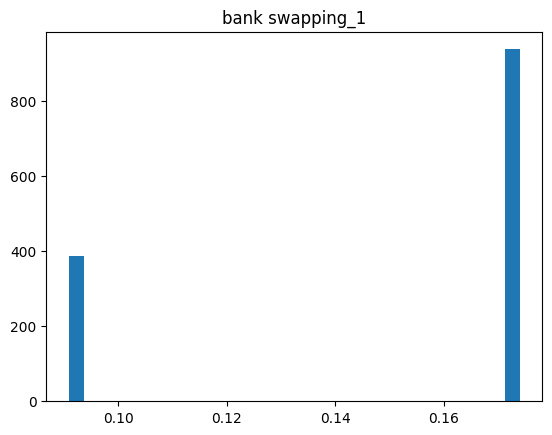

25


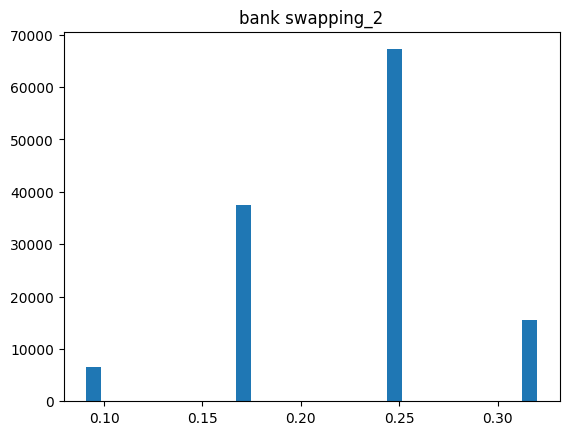

25


KeyboardInterrupt: 

In [ ]:
for dataset, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if not row['method'].startswith('swapping'):
            continue
        # distribution = []
        # w_rset = row['w_rset']
        # for w in w_rset:
        #     distribution.extend(list(w.nonzero()[0]))

        # plt.title(f"{dataset} {row['method']}")
        # plt.hist(distribution, bins=30)
        # plt.show()

        iou_distribution = []
        w_rset = row['w_rset']
        print(w_rset.shape[1])
        for i in range(w_rset.shape[0]):
            for j in range(i + 1, w_rset.shape[0]):
                iou_distribution.append(inverse_IoU(w_rset[i], w_rset[j]))
        plt.title(f"{dataset} {row['method']}")
        plt.hist(iou_distribution, bins=30)
        plt.show()

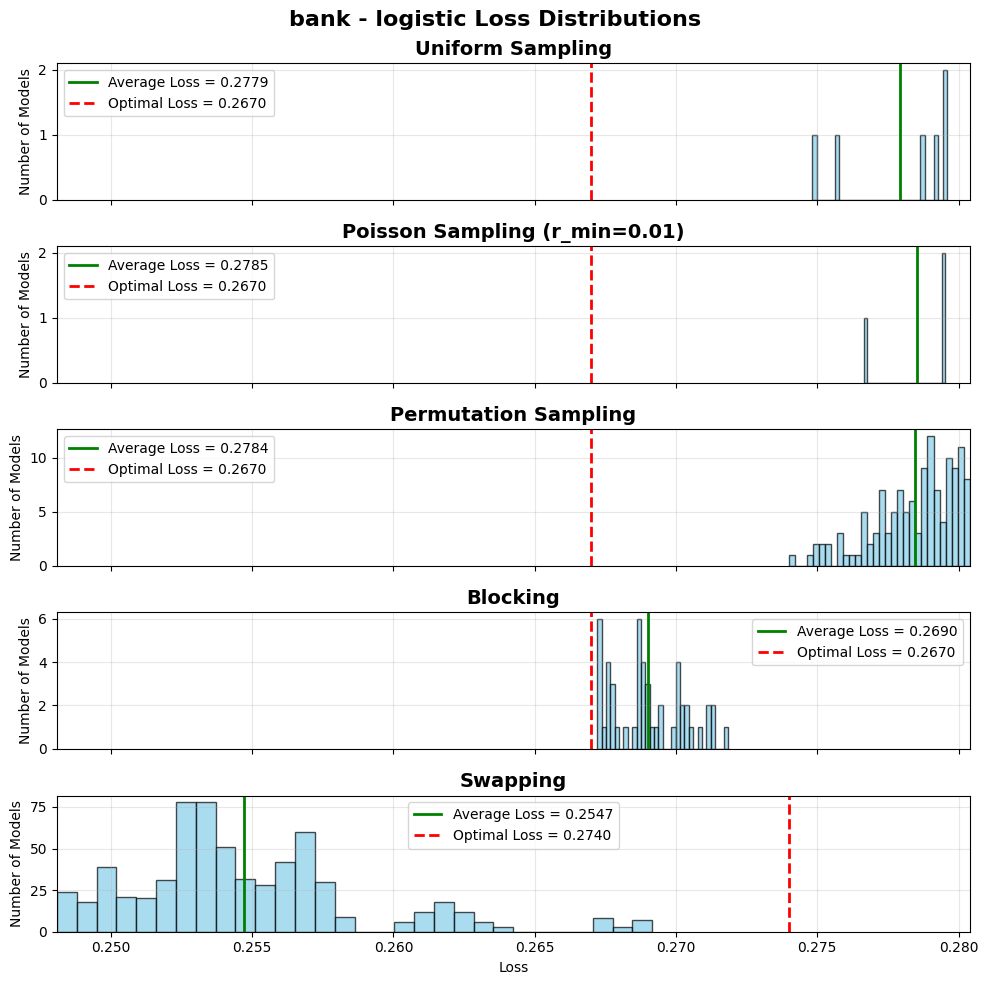

In [15]:
show_loss_distributions(all_datasets_results, "bank", "logistic")

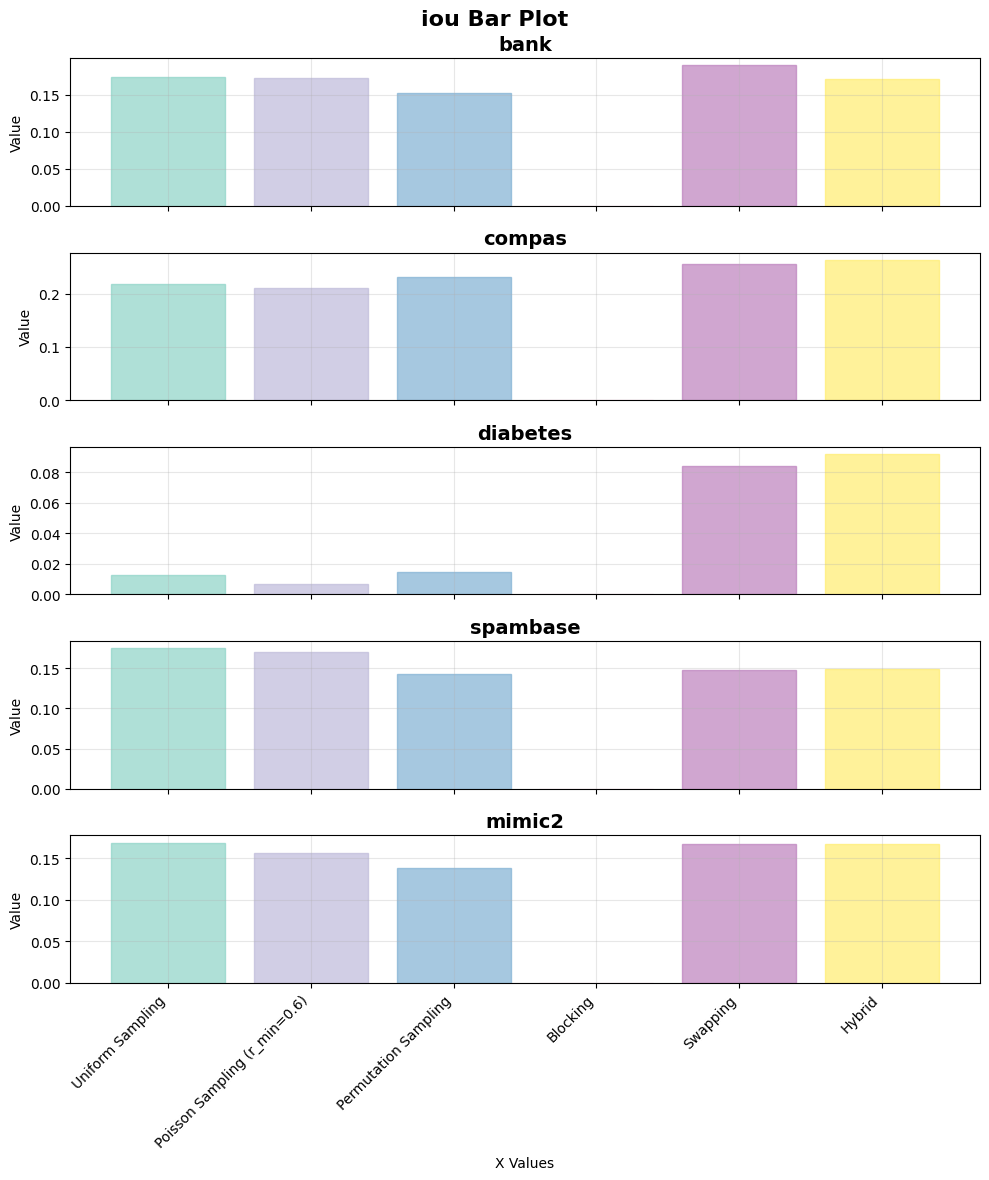

In [20]:
bar_metrics = ['accuracy', 'logistic', 'hamming', 'iou', 'euclidean', 'cosine', 'logit_variances', 'logit_distances']
bar_plot = get_bar_plot(all_datasets_results, 'iou', methods)

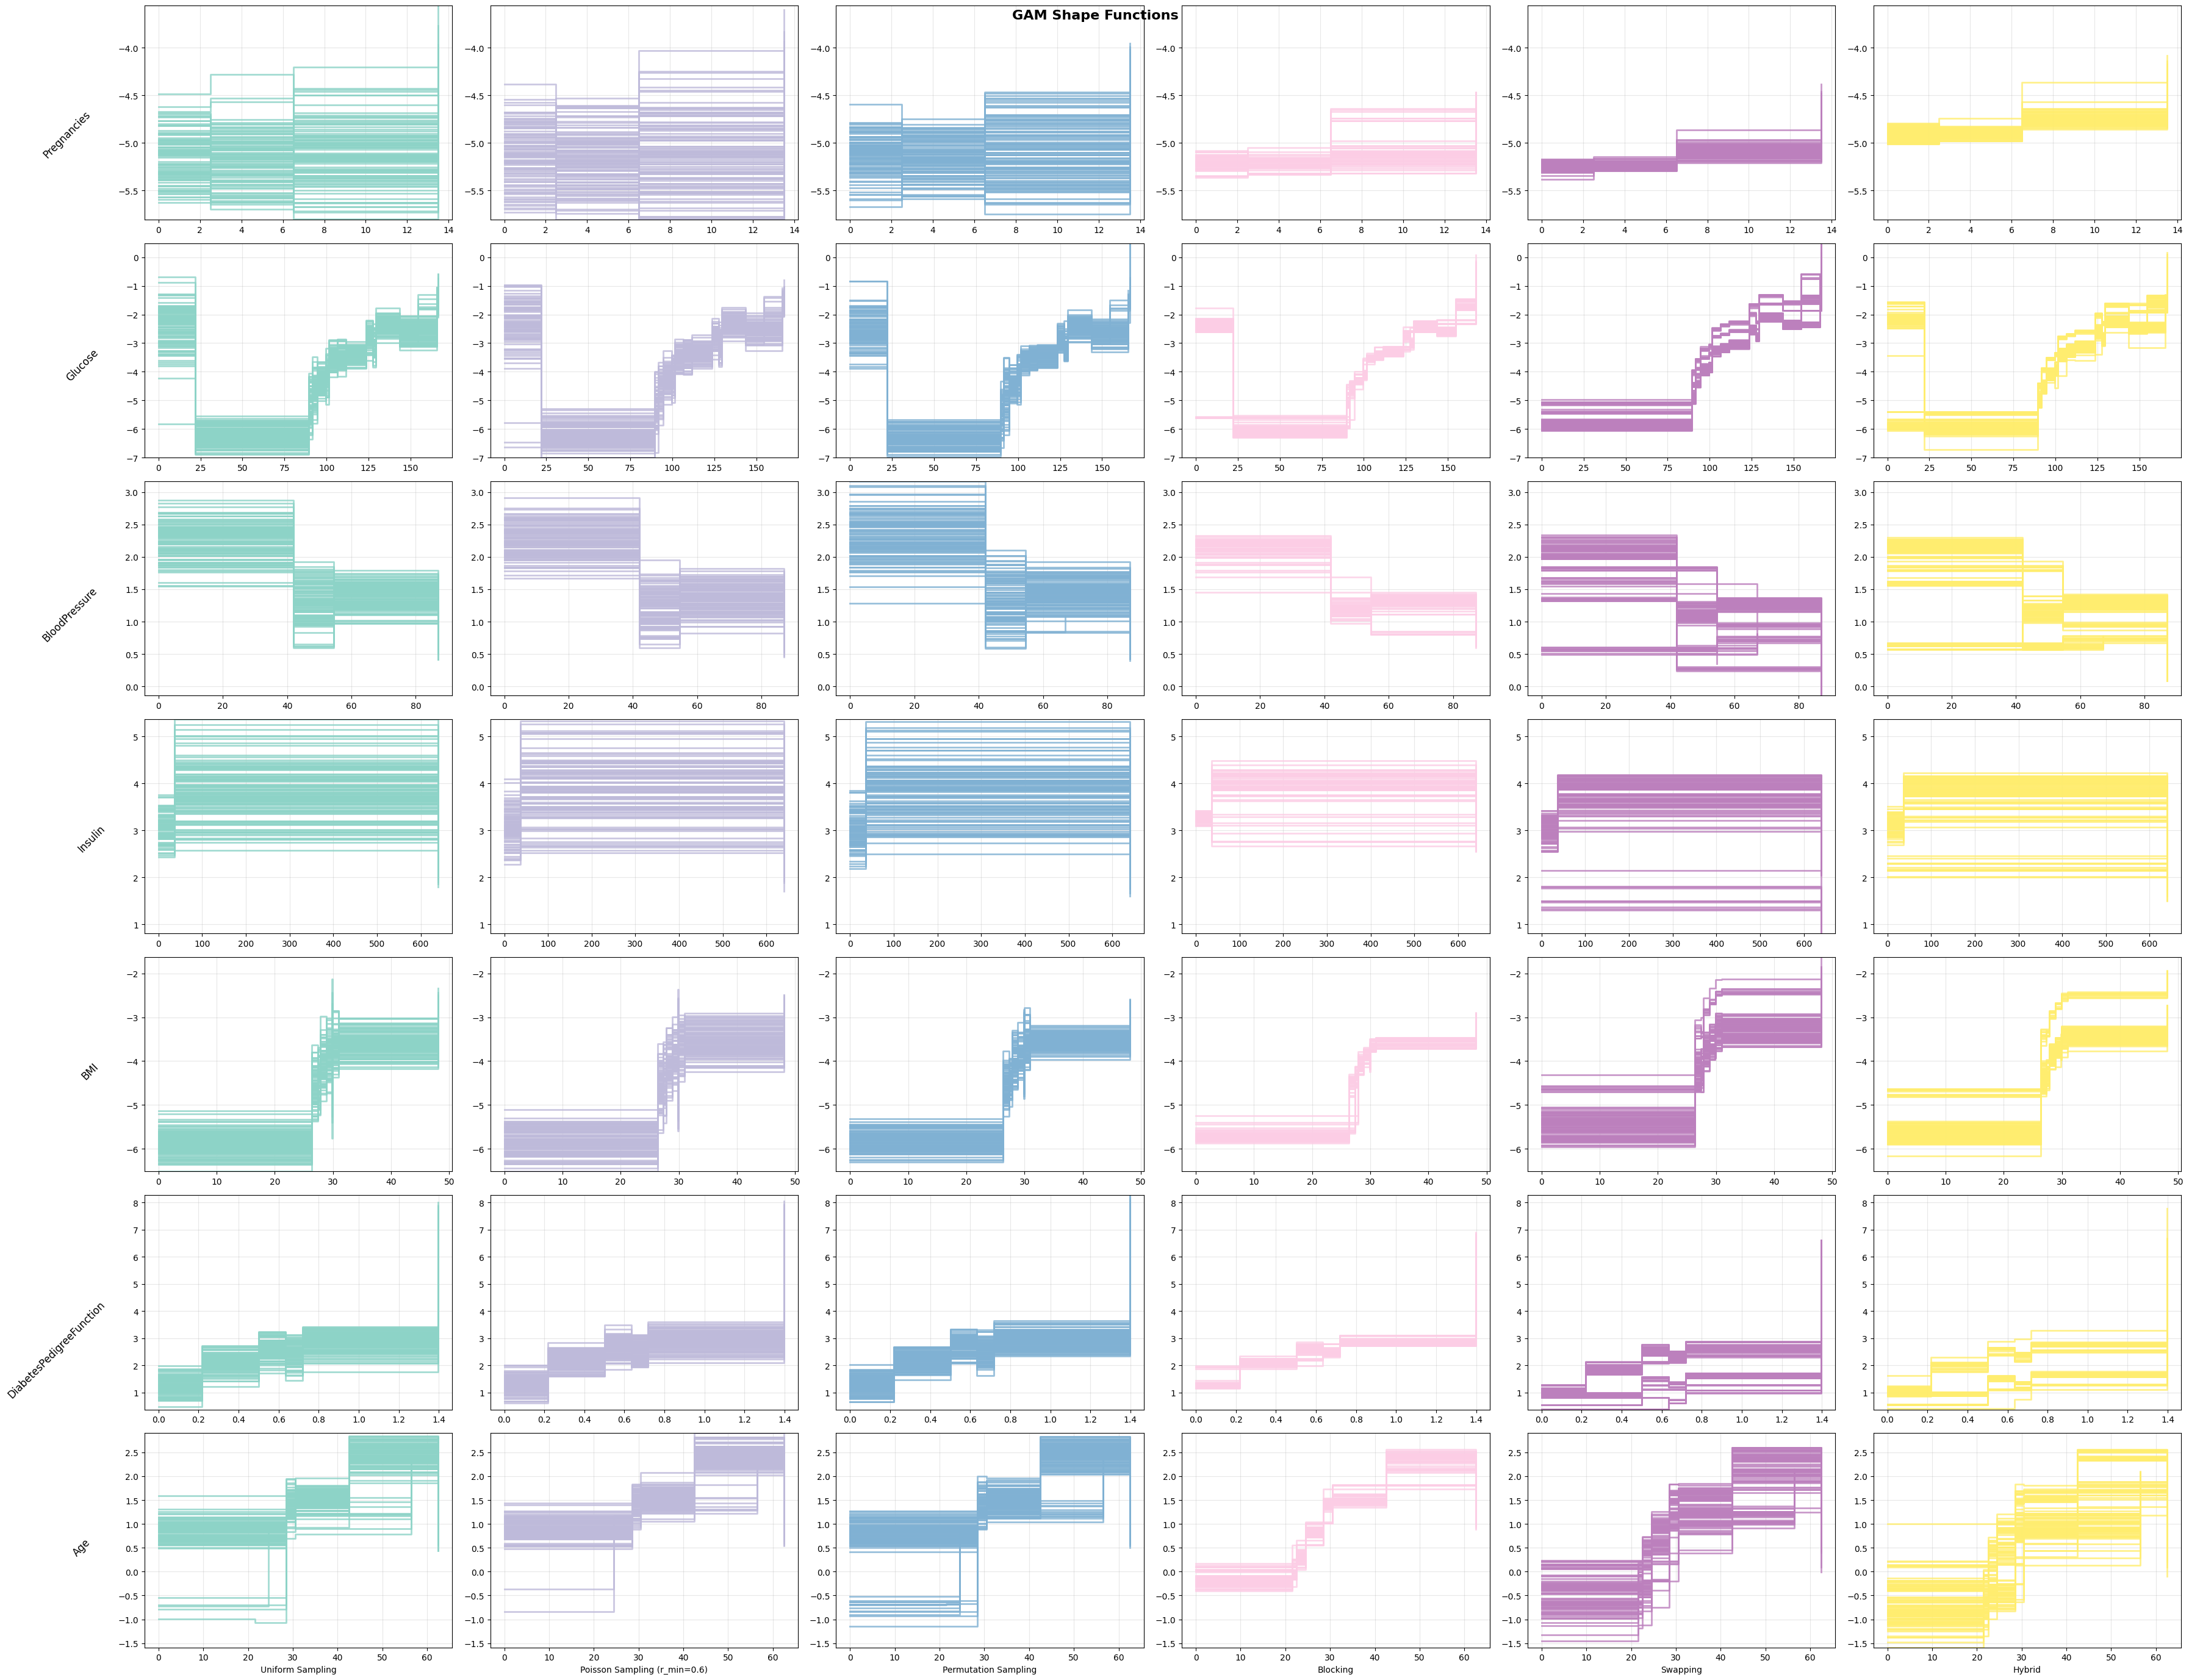

In [26]:
["bank", "compas", "diabetes", "spambase", "mimic2"]
gam = get_gam(all_datasets_results, 'diabetes')

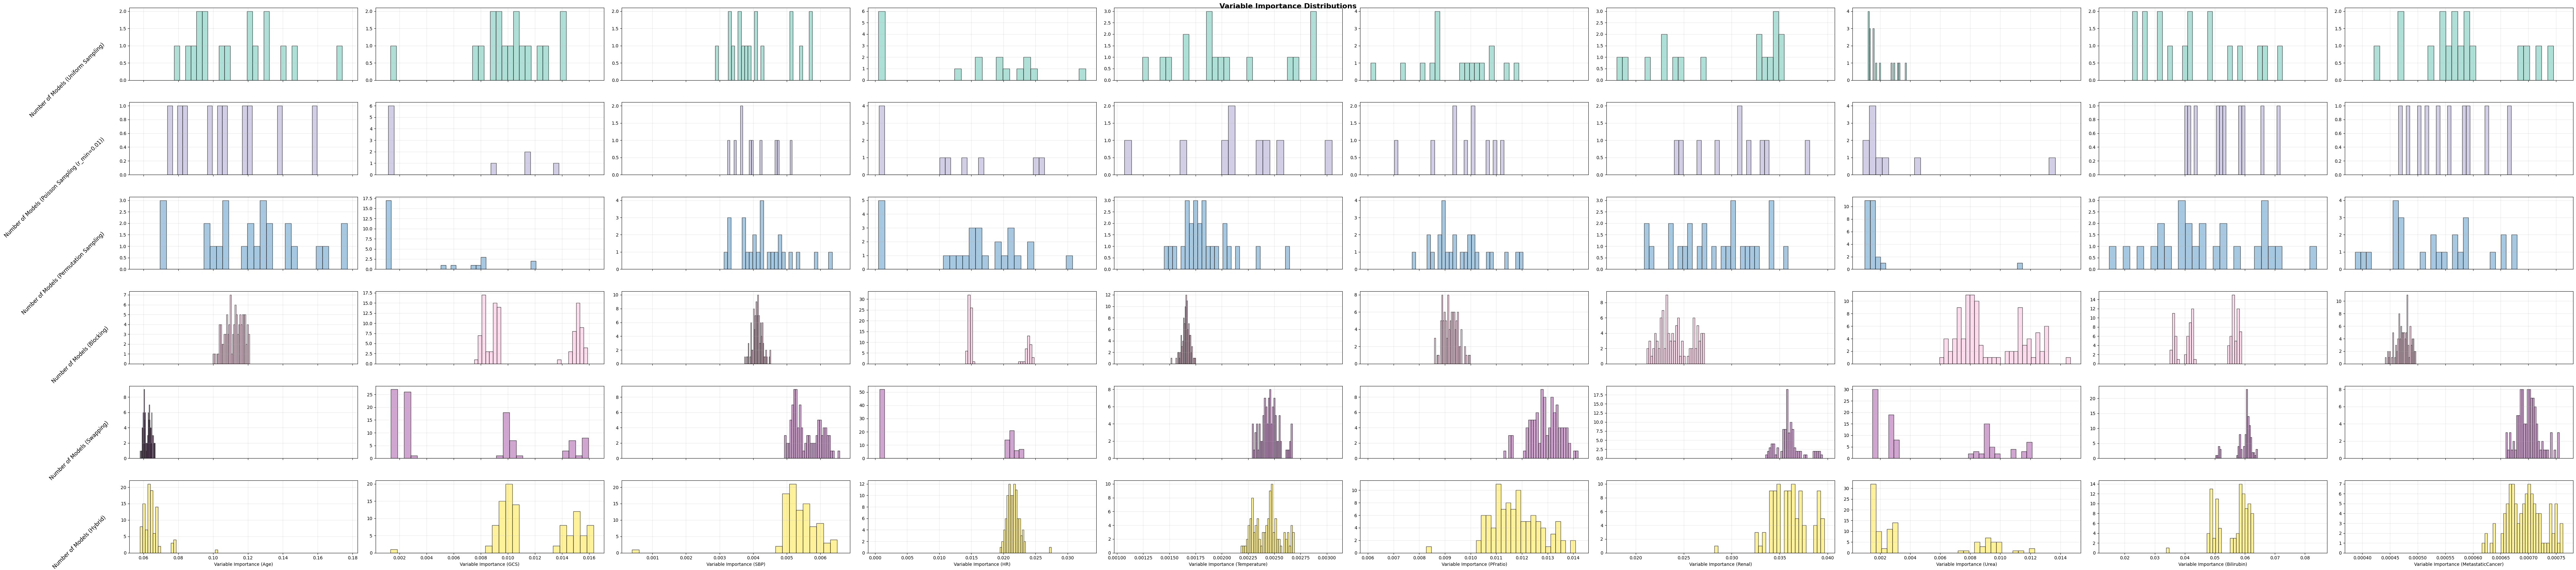

In [7]:
variable_importance = get_variable_importance(all_datasets_results, 'mimic2')

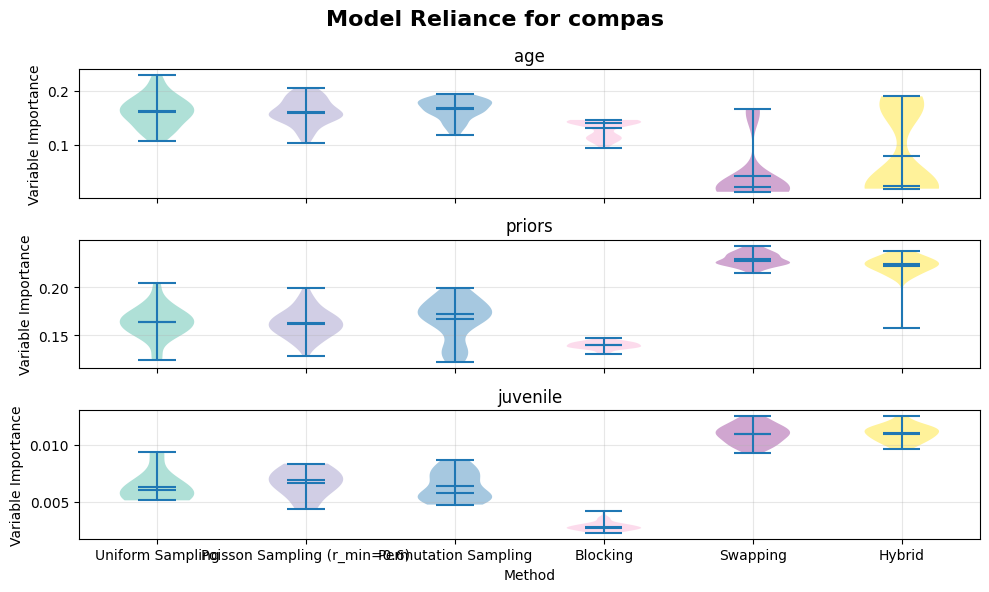

In [24]:
model_reliance = get_model_reliance(all_datasets_results, "compas")

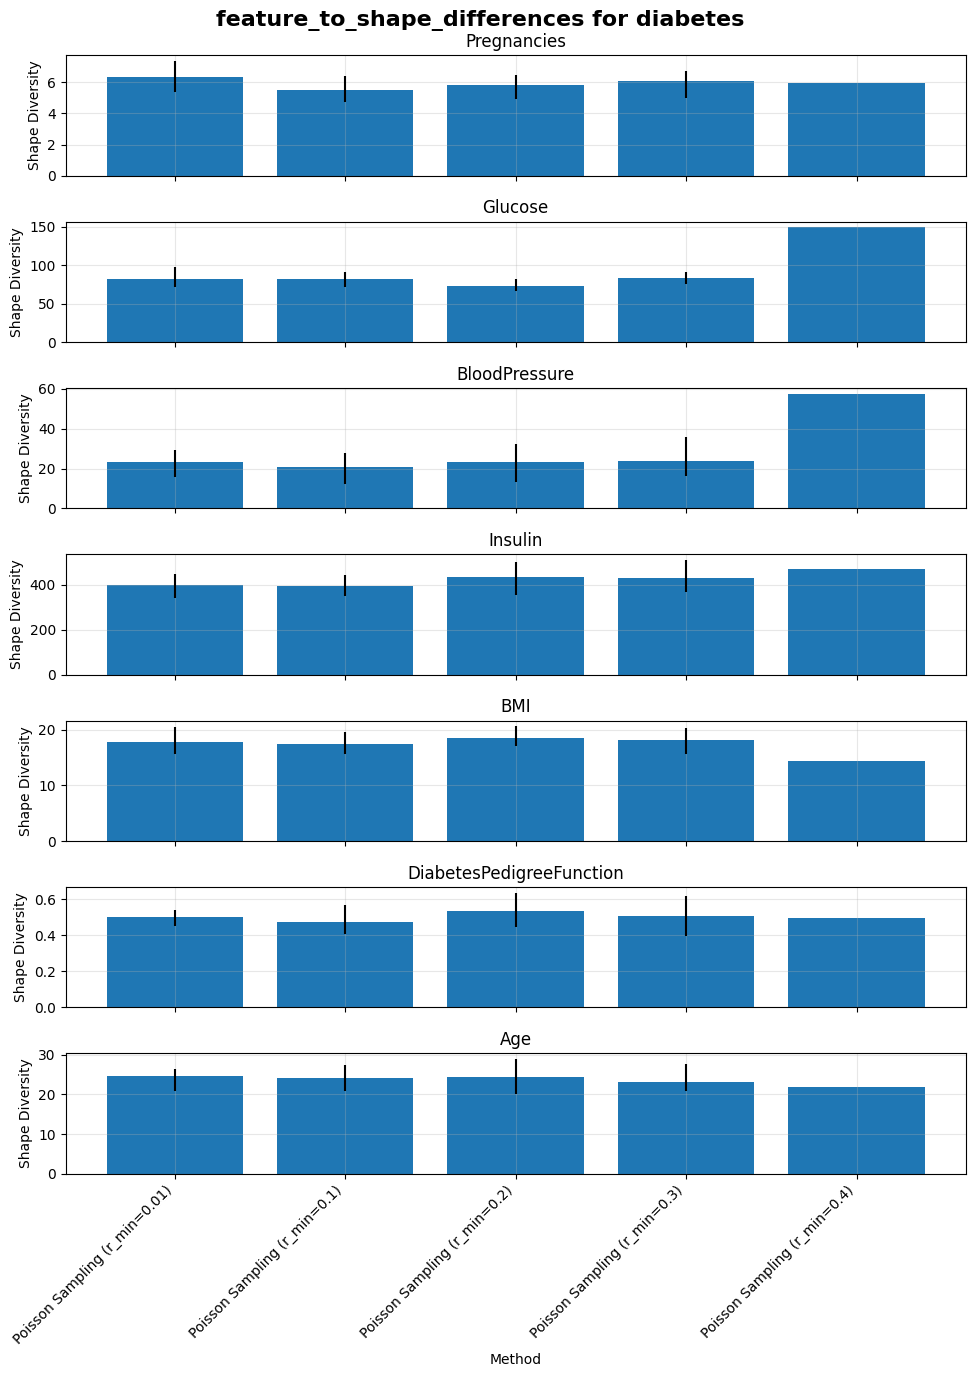

In [ ]:
fsd = get_feature_to_shape_diversity(all_datasets_results, "diabetes", feature_to_shape_metrics[0])

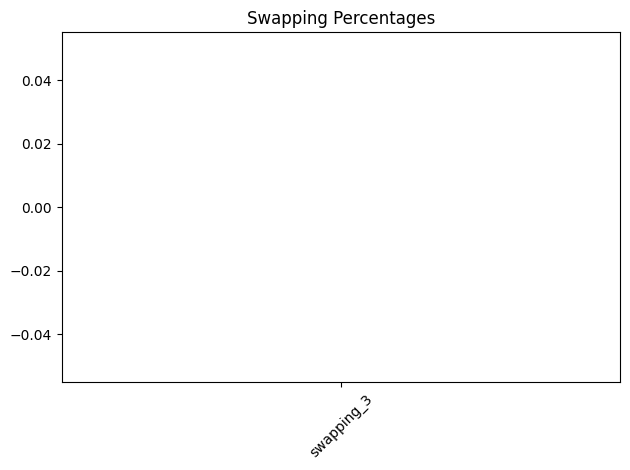

In [31]:
show_swapping_percentages(all_datasets_results, "bank")

In [18]:
get_table_results(all_datasets_results)

/var/folders/7g/zkyqkq094znbhbyfb390fvsm0000gn/T/ipykernel_55389/1045058177.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[metrics] = df[metrics].applymap(lambda v: f"{round(v[0], 3)} ({round(v[1][0], 3)}, {round(v[1][1], 3)})")
/var/folders/7g/zkyqkq094znbhbyfb390fvsm0000gn/T/ipykernel_55389/1045058177.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[metrics] = df[metrics].applymap(lambda v: f"{round(v[0], 3)} ({round(v[1][0], 3)}, {round(v[1][1], 3)})")
/var/folders/7g/zkyqkq094znbhbyfb390

,dataset,method,accuracy,iou,logit_variances,logit_distances,hamming,feature_to_shape_differences,feature_to_shape_diversities
0,bank,Uniform Sampling,"0.107 (0.103, 0.111)","0.175 (0.175, 0.175)","3.719 (2.504, 5.118)","16.177 (13.48, 19.228)","0.999 (0.979, 1.017)","{'age': [(69.5547952407888, [69.55479524 69.55...","{'age': [(1.1496660370378315, [1.14966604 1.14..."
1,bank,Poisson Sampling (r_min=0.6),"0.107 (0.103, 0.112)","0.173 (0.173, 0.173)","3.627 (2.217, 4.974)","15.95 (13.929, 18.302)","0.882 (0.863, 0.901)","{'age': [(68.74230406194283, [68.74230406 68.7...","{'age': [(1.1362364307759147, [1.13623643 1.13..."
2,bank,Permutation Sampling,"0.107 (0.102, 0.112)","0.153 (0.153, 0.153)","3.611 (2.636, 4.784)","15.761 (12.549, 18.176)","0.886 (0.807, 0.963)","{'age': [(46.865011295257055, [46.8650113 46.8...","{'age': [(0.7746282858720175, [0.77462829 0.77..."
3,bank,Blocking,"0.102 (0.101, 0.103)","0.0 (0.0, 0.0)","3.192 (2.379, 3.652)","14.518 (12.012, 16.901)","24.678 (24.678, 24.678)","{'age': [(28.960717864604288, [28.96071786 28....","{'age': [(0.47868955148106257, [0.47868955 0.4..."
4,bank,Swapping,"0.108 (0.104, 0.113)","0.19 (0.19, 0.19)","3.291 (3.149, 3.393)","14.876 (12.51, 17.109)","0.548 (0.364, 0.705)","{'age': [(115.62156432544433, [115.62156433 11...","{'age': [(1.9111002367842036, [1.91110024 1.91..."
5,bank,Hybrid,"0.107 (0.102, 0.112)","0.172 (0.172, 0.172)","3.377 (3.203, 3.433)","14.998 (12.517, 17.374)","0.617 (0.481, 0.805)","{'age': [(102.66536765846136, [102.66536766 10...","{'age': [(1.6969482257596917, [1.69694823 1.69..."
6,compas,Uniform Sampling,"0.327 (0.319, 0.337)","0.219 (0.219, 0.219)","0.982 (0.728, 1.297)","8.538 (7.208, 9.813)","5.668 (5.351, 6.013)","{'age': [(19.15450791649658, [19.15450792 19.1...","{'age': [(0.4228913276966985, [0.42289133 0.42..."
7,compas,Poisson Sampling (r_min=0.6),"0.326 (0.318, 0.336)","0.21 (0.21, 0.21)","0.968 (0.713, 1.242)","8.44 (7.269, 9.549)","4.874 (4.751, 4.998)","{'age': [(17.086085882674475, [17.08608588 17....","{'age': [(0.38241296414081155, [0.38241296 0.3..."
8,compas,Permutation Sampling,"0.327 (0.318, 0.339)","0.232 (0.232, 0.232)","0.958 (0.604, 1.262)","8.4 (7.346, 9.47)","4.879 (4.631, 5.144)","{'age': [(17.911492911337334, [17.91149291 17....","{'age': [(0.41872124589657467, [0.41872125 0.4..."
9,compas,Blocking,"0.32 (0.314, 0.329)","0.0 (0.0, 0.0)","0.836 (0.737, 0.881)","7.731 (6.49, 8.702)","604.067 (604.067, 604.067)","{'age': [(4.395992588755547, [4.39599259 4.395...","{'age': [(0.10029623215163995, [0.10029623 0.1..."


In [ ]:
bar_metrics = ['iou', 'euclidean']
for bm in bar_metrics:
    fig = get_bar_plot(all_datasets_results, bm, methods)  # this should create/return the figure
    fig.savefig(f'figures/{bm}_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_gam(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_gam.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names[1:]:
    fig = get_model_reliance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_model_reliance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for fsd in feature_to_shape_metrics:
    fig = get_feature_to_shape_diversity(all_datasets_results, dn, fsd)
    fig.savefig(f'figures/{fsd}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)